# Multi-sample cluster size distribution

Loads any number of AFA export files, applies one shared composition filter, clusters each sample independently (each with its own edge-to-edge distance threshold), and plots the resulting cluster-size distributions superimposed on one chart for comparison.

## Libraries and imports

In [19]:
import sys
import subprocess
import importlib.util

def _ensure_packages(packages):
    missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
    if missing:
        print('Installing missing packages:', missing)
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
        for pkg in missing:
            importlib.import_module(pkg)

_ensure_packages(['numpy', 'pandas', 'matplotlib', 'openpyxl', 'scipy'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp
from scipy.spatial import ConvexHull

%matplotlib inline

## Samples to compare

Add, remove, or edit entries in `SAMPLES` — any number of samples is supported, the rest of the
notebook loops over whatever is in this list.

- `name`: label used in the legend
- `file`: path to the AFA `.xlsx` export for this sample
- `threshold`: edge-to-edge clustering distance threshold for this sample, in µm
- `area_mm2`: scanned area for this sample, in mm² (the "Area analyzed" value from that sample's own info/setup — each sample can have a different scanned area)

In [20]:
SAMPLES = [
    {'name': 'C1', 'file': 'C1.xlsx', 'threshold': 38.02, 'area_mm2': 10.8},
    {'name': 'C2', 'file': 'C2.xlsx', 'threshold': 40.21, 'area_mm2': 10.8},
    #{'name': 'E3', 'file': '3.xlsx', 'threshold': 48.87, 'area_mm2': 9.9},
    # add as many samples as needed
]

## Composition filter

One shared filter, applied identically to every sample. `row` gives access to any of the
element weight-percent columns (`O`, `Mg`, `Al`, `Si`, `S`, `Ca`, `Mn`, `Fe`, `Zr`, `Ti`) as well
as `ECD`, `Aspect`, `Area`.

In [21]:
def sample_filter(row):
    # Edit this filter — it is applied identically to every sample in SAMPLES.
    return row['Ti'] >= 5 and row['Fe'] <= 50

## AFA file loader

In [22]:
# Maps AFA export column headers (row 1 of the sheet) to the short names used below.
AFA_COLUMNS = {
    'Feature': 'Feature',
    'Stage X (mm)': 'X',
    'Stage Y (mm)': 'Y',
    'ECD (µm)': 'ECD',
    'Aspect Ratio': 'Aspect',
    'Area (sq. µm)': 'Area',
    'Spectrum': 'Spectrum',
    'O (Wt%)': 'O',
    'Mg (Wt%)': 'Mg',
    'Al (Wt%)': 'Al',
    'Si (Wt%)': 'Si',
    'S (Wt%)': 'S',
    'Ca (Wt%)': 'Ca',
    'Mn (Wt%)': 'Mn',
    'Fe (Wt%)': 'Fe',
    'Zr (Wt%)': 'Zr',
    'Ti (Wt%)': 'Ti',
}
NUMERIC_COLUMNS = ['X', 'Y', 'ECD', 'Aspect', 'Area', 'O', 'Mg', 'Al', 'Si', 'S', 'Ca', 'Mn', 'Fe', 'Zr', 'Ti']


def load_afa_file(path):
    # AFA export layout: row 0 = headers, row 1 = units, data starts row 2.
    raw = pd.read_excel(path, sheet_name=0, header=None, dtype=str).fillna('').astype(str).values.tolist()
    n_rows = len(raw)
    header = raw[0]

    columns = {dst: [''] * (n_rows - 2) for dst in AFA_COLUMNS.values()}
    for col_idx, name in enumerate(header):
        if name in AFA_COLUMNS:
            dst = AFA_COLUMNS[name]
            for row_idx in range(2, n_rows):
                columns[dst][row_idx - 2] = raw[row_idx][col_idx]

    out = pd.DataFrame(columns)
    for col in NUMERIC_COLUMNS:
        out[col] = pd.to_numeric(out[col], errors='coerce').fillna(0.0)
    return out

## Clustering algorithm

Same edge-to-edge distance clustering as the single-sample notebook, generalized to take a
per-call distance threshold so each sample can use its own value.

In [23]:
def cluster_features(x_mm, y_mm, ecd_um, distance_threshold):
    n = len(x_mm)
    x = np.asarray(x_mm, dtype=float) * 1000.0  # mm -> µm
    y = np.asarray(y_mm, dtype=float) * 1000.0
    ecd = np.asarray(ecd_um, dtype=float)

    cluster_ids = [-1] * n
    current_cluster = 1

    for start in range(n):
        if cluster_ids[start] != -1 or ecd[start] == 0:
            continue

        cluster_members = {start}
        to_check = [start]

        while to_check:
            current = to_check.pop(0)
            cluster_ids[current] = current_cluster

            for candidate in range(n):
                if cluster_ids[candidate] != -1 or ecd[candidate] == 0:
                    continue

                min_edge_distance = float('inf')
                for member in cluster_members:
                    dx = x[candidate] - x[member]
                    dy = y[candidate] - y[member]
                    center_distance = np.hypot(dx, dy)
                    edge_distance = center_distance - ecd[candidate] / 2 - ecd[member] / 2
                    min_edge_distance = min(min_edge_distance, edge_distance)

                if min_edge_distance <= distance_threshold and candidate not in cluster_members:
                    cluster_members.add(candidate)
                    to_check.append(candidate)

        current_cluster += 1

    return np.array(cluster_ids), ecd, x, y


def cluster_max_lengths(cluster_ids, x_um, y_um, ecd_um):
    # Max end-to-end length (including feature radii) per cluster id.
    max_distances = {}
    for cid in set(cluster_ids):
        idxs = [i for i, c in enumerate(cluster_ids) if c == cid]

        if len(idxs) == 1:
            max_distances[cid] = ecd_um[idxs[0]]
            continue

        pts = np.array([[x_um[i], y_um[i]] for i in idxs])

        if len(idxs) >= 3:
            try:
                hull = ConvexHull(pts)
                hull_idx = [idxs[v] for v in hull.vertices]
                hull_pts = pts[hull.vertices]
                max_dist = 0
                for i in range(len(hull_pts)):
                    for j in range(i + 1, len(hull_pts)):
                        d = np.hypot(*(hull_pts[i] - hull_pts[j]))
                        total = d + ecd_um[hull_idx[i]] / 2 + ecd_um[hull_idx[j]] / 2
                        max_dist = max(max_dist, total)
                max_distances[cid] = max_dist
            except Exception:
                max_dist = 0
                for i in range(len(pts)):
                    for j in range(i + 1, len(pts)):
                        d = np.hypot(*(pts[i] - pts[j]))
                        total = d + ecd_um[idxs[i]] / 2 + ecd_um[idxs[j]] / 2
                        max_dist = max(max_dist, total)
                max_distances[cid] = max_dist
        else:
            d = np.hypot(*(pts[0] - pts[1]))
            max_distances[cid] = d + ecd_um[idxs[0]] / 2 + ecd_um[idxs[1]] / 2

    return max_distances

## Process each sample

Load -> apply the shared filter -> cluster with that sample's own threshold -> compute cluster-size stats.

In [24]:
sample_results = []

for cfg in SAMPLES:
    df = load_afa_file(cfg['file'])

    mask = df.apply(lambda r: bool(sample_filter(r)), axis=1)
    filtered = df[mask].reset_index(drop=True)
    filtered = filtered[
        (filtered['Feature'] != '') & (filtered['X'] != 0) & (filtered['Y'] != 0) & (filtered['ECD'] != 0)
    ].reset_index(drop=True)

    cluster_ids, ecd_um, x_um, y_um = cluster_features(
        filtered['X'].tolist(), filtered['Y'].tolist(), filtered['ECD'].tolist(), cfg['threshold']
    )
    max_lengths = cluster_max_lengths(cluster_ids, x_um, y_um, ecd_um)

    cluster_results = pd.DataFrame({
        'Feature ID': filtered['Feature'],
        'X (mm)': filtered['X'],
        'Y (mm)': filtered['Y'],
        'Cluster': cluster_ids,
        'Max Length (µm)': [max_lengths[c] for c in cluster_ids],
    })

    counts_per_cluster = cluster_results.groupby('Cluster').size()
    single = counts_per_cluster[counts_per_cluster == 1].index
    multi = counts_per_cluster[counts_per_cluster > 1].index

    cluster_lengths = cluster_results[cluster_results['Cluster'].isin(multi)].groupby('Cluster')['Max Length (µm)'].first()
    non_clustered_count = counts_per_cluster.loc[single].sum() if len(single) else 0
    non_clustered_fraction = non_clustered_count / counts_per_cluster.sum() if counts_per_cluster.sum() else 0.0

    sample_results.append({
        'name': cfg['name'],
        'file': cfg['file'],
        'threshold': cfg['threshold'],
        'area_mm2': cfg['area_mm2'],
        'n_features': len(filtered),
        'cluster_results': cluster_results,
        'cluster_lengths': cluster_lengths,
        'n_clusters': len(cluster_lengths),
        'mean_length': cluster_lengths.mean() if len(cluster_lengths) else float('nan'),
        'median_length': cluster_lengths.median() if len(cluster_lengths) else float('nan'),
        'non_clustered_fraction': non_clustered_fraction,
    })

    print(f"{cfg['name']}: {len(filtered)} features after filter -> "
          f"{len(set(cluster_ids))} clusters ({len(cluster_lengths)} multi-feature)")

C1: 1649 features after filter -> 960 clusters (366 multi-feature)
C2: 1059 features after filter -> 541 clusters (197 multi-feature)


## Cluster size distribution — all samples superimposed

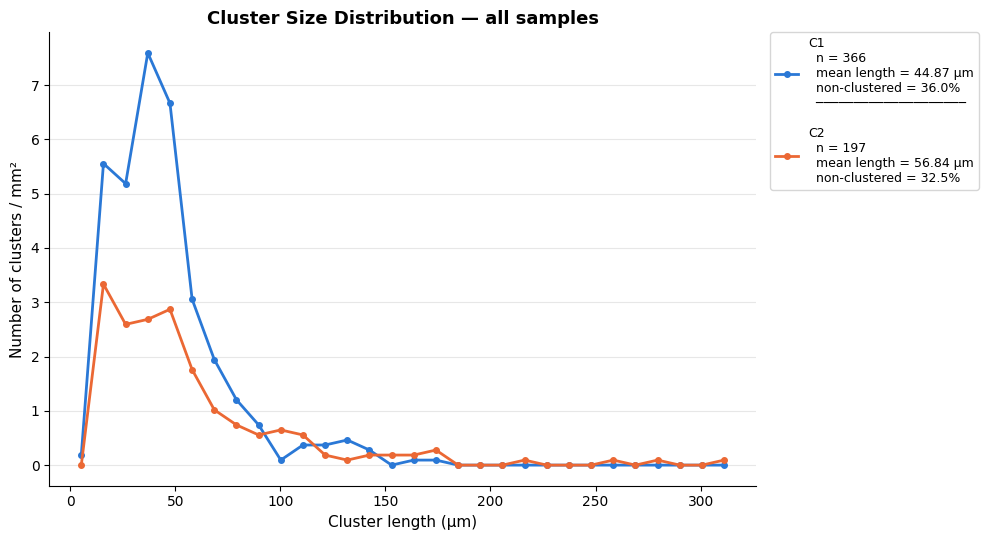

In [25]:
# --- Axis / binning control ---
# AUTO_SCALE = True  -> bin range and axis limits derive from the combined data.
# AUTO_SCALE = False -> bins and axes are forced to X_SCALE / Y_SCALE, so runs stay comparable.
AUTO_SCALE = True
X_SCALE = (0, 200)   # (min, max) cluster length in µm, used only when AUTO_SCALE is False
Y_SCALE = (0, 3.5)   # (min, max) clusters per mm², used only when AUTO_SCALE is False
NUM_BINS = 30

# Fixed categorical color order (colorblind-checked) — extend/replace if you have more than 8 samples.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

all_lengths = np.concatenate([r['cluster_lengths'].to_numpy() for r in sample_results if len(r['cluster_lengths'])]) \
    if any(len(r['cluster_lengths']) for r in sample_results) else np.array([0.0])

bin_range = X_SCALE if not AUTO_SCALE else (0, max(all_lengths.max(), 1.0))
bin_edges = np.linspace(bin_range[0], bin_range[1], NUM_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pp.rcParams['font.family'] = 'sans-serif'
fig, ax = pp.subplots(figsize=(10, 5.5))

n_samples = len(sample_results)
for i, r in enumerate(sample_results):
    color = PALETTE[i % len(PALETTE)]
    counts, _ = np.histogram(r['cluster_lengths'], bins=bin_edges)
    density = counts / r['area_mm2']

    label_lines = [
        r['name'],
        f"  n = {r['n_clusters']}",
        f"  mean length = {r['mean_length']:.2f} µm",
        f"  non-clustered = {r['non_clustered_fraction']:.1%}",
    ]
    if i < n_samples - 1:
        label_lines.append('  ' + '─' * 20)
    label = '\n'.join(label_lines)

    ax.plot(bin_centers, density, color=color, linewidth=2, marker='o', markersize=4, label=label)

ax.set_xlabel('Cluster length (µm)', fontsize=11)
ax.set_ylabel('Number of clusters / mm²', fontsize=11)
ax.set_title('Cluster Size Distribution — all samples', fontsize=13, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

if not AUTO_SCALE:
    ax.set_xlim(X_SCALE)
    ax.set_ylim(Y_SCALE)

ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0,
          labelspacing=1.3, handlelength=1.8, frameon=True)

pp.tight_layout()
fig.savefig('cluster_size_distribution_all_samples.png', dpi=150, bbox_inches='tight')
pp.show()

## Export

In [26]:
summary_df = pd.DataFrame([{
    'Sample': r['name'],
    'File': r['file'],
    'Threshold (µm)': r['threshold'],
    'Area analyzed (mm²)': r['area_mm2'],
    'Features after filter': r['n_features'],
    'Clusters (multi-feature)': r['n_clusters'],
    'Mean cluster length (µm)': r['mean_length'],
    'Median cluster length (µm)': r['median_length'],
    'Non-clustered fraction': r['non_clustered_fraction'],
} for r in sample_results])

summary_df.to_excel('cluster_summary_all_samples.xlsx', index=False)
print(summary_df.to_string(index=False))

for r in sample_results:
    r['cluster_results'].to_excel(f"{r['name']}_clustering_results.xlsx", index=False)

print("\nExported: cluster_summary_all_samples.xlsx, cluster_size_distribution_all_samples.png, "
      "and one <name>_clustering_results.xlsx per sample.")

Sample    File  Threshold (µm)  Area analyzed (mm²)  Features after filter  Clusters (multi-feature)  Mean cluster length (µm)  Median cluster length (µm)  Non-clustered fraction
    C1 C1.xlsx           38.02                 10.8                   1649                       366                 44.868371                   40.528443                0.360218
    C2 C2.xlsx           40.21                 10.8                   1059                       197                 56.836555                   43.953707                0.324835

Exported: cluster_summary_all_samples.xlsx, cluster_size_distribution_all_samples.png, and one <name>_clustering_results.xlsx per sample.


## Per-sample bar charts — features per cluster vs. cluster size

One bar chart per sample (stacked vertically), using only multi-feature clusters (same as the
distribution plot above). X axis is cluster size (max length, µm); Y axis is features per cluster.

- If a sample has **20 or fewer** clusters, each cluster is drawn as its own bar at its size.
- If it has **more than 20** clusters, sizes are grouped into bins and each bar's height is the
  **average number of features per cluster** among the clusters in that bin — so the height stays
  on the same "features per cluster" scale as the unbinned case.

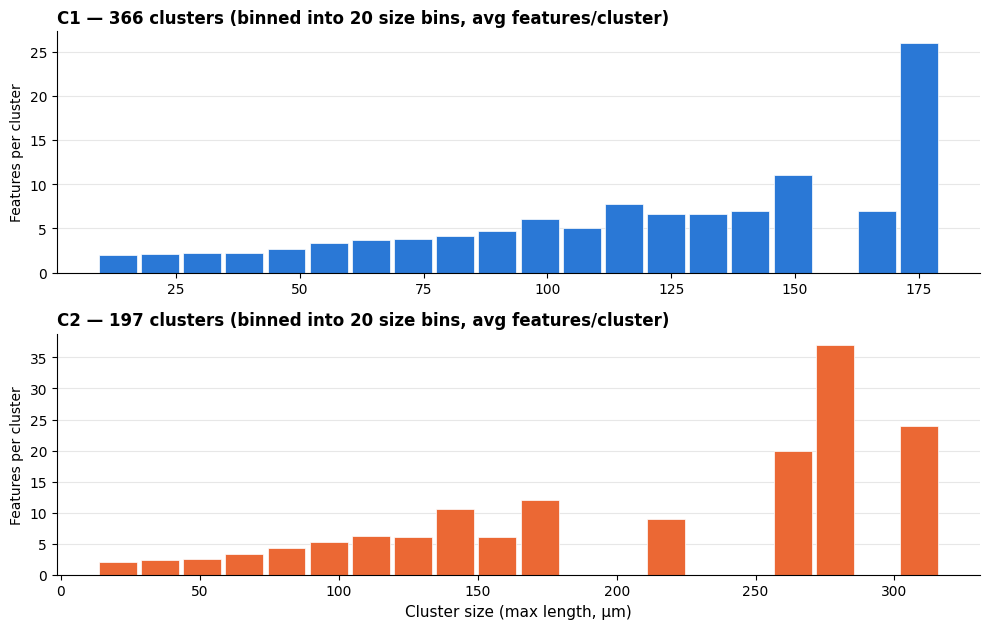

In [27]:
# Bar chart per sample: number of features (y) vs. cluster size (x).
# Uses multi-feature clusters only (consistent with the distribution plot).
# <= 20 clusters -> one bar per cluster; > 20 clusters -> bin sizes and average the feature
# counts of the clusters in each bin (so height stays "features per cluster", comparable to
# the unbinned case).
BAR_BIN_THRESHOLD = 20   # bin only when a sample has more than this many clusters
BAR_NUM_BINS = 20        # number of size bins to use when binning

n_samples = len(sample_results)
fig, axes = pp.subplots(n_samples, 1, figsize=(10, 3.2 * n_samples), squeeze=False)
axes = axes[:, 0]

for i, (ax, r) in enumerate(zip(axes, sample_results)):
    color = PALETTE[i % len(PALETTE)]
    cr = r['cluster_results']

    # Per-cluster size (max length) and feature count, multi-feature clusters only.
    grp = cr.groupby('Cluster')
    counts = grp.size()
    multi = counts[counts > 1].index
    sizes = grp['Max Length (µm)'].first().loc[multi]
    counts = counts.loc[multi]

    n_clusters = len(sizes)

    if n_clusters == 0:
        ax.text(0.5, 0.5, 'No multi-feature clusters', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='0.4')
        ax.set_title(r['name'], fontsize=12, fontweight='bold', loc='left')
        continue

    if n_clusters <= BAR_BIN_THRESHOLD:
        # One bar per cluster, positioned at its actual size.
        order = np.argsort(sizes.to_numpy())
        x = sizes.to_numpy()[order]
        y = counts.to_numpy()[order]
        span = (x.max() - x.min()) if x.max() > x.min() else 1.0
        width = span / max(n_clusters, 1) * 0.8
        width = max(width, x.max() * 0.01)  # keep bars visible even when sizes are close
        ax.bar(x, y, width=width, color=color, edgecolor='white', linewidth=0.5)
        subtitle = f'{n_clusters} clusters (one bar each)'
    else:
        # Bin sizes; each bar's height is the AVERAGE number of features per cluster in that bin.
        edges = np.linspace(sizes.min(), sizes.max(), BAR_NUM_BINS + 1)
        bin_idx = np.clip(np.digitize(sizes.to_numpy(), edges) - 1, 0, BAR_NUM_BINS - 1)
        feature_totals = np.zeros(BAR_NUM_BINS)
        cluster_counts = np.zeros(BAR_NUM_BINS)
        for b, c in zip(bin_idx, counts.to_numpy()):
            feature_totals[b] += c
            cluster_counts[b] += 1
        mean_features = np.divide(feature_totals, cluster_counts,
                                  out=np.zeros(BAR_NUM_BINS), where=cluster_counts > 0)
        centers = (edges[:-1] + edges[1:]) / 2
        bar_width = (edges[1] - edges[0]) * 0.9
        ax.bar(centers, mean_features, width=bar_width, color=color, edgecolor='white', linewidth=0.5)
        subtitle = f'{n_clusters} clusters (binned into {BAR_NUM_BINS} size bins, avg features/cluster)'

    ax.set_title(f"{r['name']} — {subtitle}", fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Features per cluster', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[-1].set_xlabel('Cluster size (max length, µm)', fontsize=11)

pp.tight_layout()
fig.savefig('features_per_cluster_size_by_sample.png', dpi=150, bbox_inches='tight')
pp.show()